# ==============================================================================
# 📺 MARKETING MULTI-CHANNEL ATTRIBUTION: ADVERTISING SALES VIA EXTRA TREES REGRESSOR
# ==============================================================================
### Core Theoretical Principles:
Extremely Randomized Trees (Extra Trees; Geurts et al., 2006) for regression aggregates $M$ unpruned decision trees trained on the complete dataset (`bootstrap=False`):
$$\hat{y}_{\text{ET}}(x) = \frac{1}{M} \sum_{m=1}^{M} h_m(x)$$

Unlike Random Forests which evaluate all possible split cut-points for each sampled candidate feature, Extra Trees chooses a single random cut-point uniformly drawn from the empirical range $[\min(x_j), \max(x_j)]$ for each candidate feature:
$$c_j \sim \text{Uniform}(\min(x_j), \max(x_j))$$
The candidate split with the highest reduction in Mean Squared Error (MSE) is chosen. This yields exceptionally fast training and minimizes the correlation among base trees!


In [1]:
# STEP 1: ENTERPRISE ENVIRONMENT & REPRODUCIBILITY SEED
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ STEP 1: Enterprise ExtraTrees Regressor Environment initialized.")


✅ STEP 1: Enterprise ExtraTrees Regressor Environment initialized.


## 📥 STEP 2 & 3: RAW DATASET INGESTION & 3-SECOND HEALTH AUDIT
Loading Advertising media spend dataset (200 campaign records across TV, Radio, Newspaper).


In [2]:
# STEP 2 & 3: INGESTION & DATASET HARMONIZATION
data_path = 'data/advertising/advertising.csv'
df = pd.read_csv(data_path)

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df = df.rename(columns={
    'TV Ad Budget ($)': 'tv',
    'Radio Ad Budget ($)': 'radio',
    'Newspaper Ad Budget ($)': 'newspaper',
    'Sales ($)': 'sales'
})
df.columns = [c.strip().lower().split(' ')[0] for c in df.columns]

print(f"📊 Dataset Shape: {df.shape[0]} campaigns, {df.shape[1]} attributes")
print(f"Sales Target Summary:\n{df['sales'].describe().round(2)}")
df.head(3)


📊 Dataset Shape: 200 campaigns, 4 attributes
Sales Target Summary:
count    200.00
mean      14.02
std        5.22
min        1.60
25%       10.38
50%       12.90
75%       17.40
max       27.00
Name: sales, dtype: float64


,tv,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3


## 🧹 STEP 4 & 5: STRICT SEGREGATION & HYGIENE
Separating features and continuous target `sales`.


In [3]:
# STEP 4 & 5: SEGREGATION & HYGIENE
X = df.drop(columns=['sales'])
y = df['sales']

print(f"Marketing Channels: {X.columns.tolist()}")
print(f"Missing attributes: {X.isnull().sum().sum()}")


Marketing Channels: ['tv', 'radio', 'newspaper']
Missing attributes: 0


## ✂️ STEP 6: ZERO-DATA-LEAKAGE SPLIT
80% Train, 20% Test split.


In [4]:
# STEP 6: TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train Campaigns: {X_train.shape[0]}")
print(f"Test Campaigns : {X_test.shape[0]}")


Train Campaigns: 160
Test Campaigns : 40


## ⚙️ STEP 7: PREPROCESSOR DESIGN
Constructing preprocessor pipeline.


In [5]:
# STEP 7: PREPROCESSOR DESIGN
preprocessor = Pipeline([
    ('scaler', StandardScaler())
])
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
print(f"Preprocessed feature space shape: {X_train_prep.shape}")


Preprocessed feature space shape: (160, 3)


## ⚔️ STEP 8: BASELINE DUEL (DUMMY VS SINGLE TREE VS EXTRA TREES)
Comparing baseline mean dummy and single decision tree against ExtraTrees with 100 trees.


In [6]:
# STEP 8: BASELINE BENCHMARK
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
r2_dummy = r2_score(y_test, dummy.predict(X_test))

single_tree = DecisionTreeRegressor(random_state=42)
single_tree.fit(X_train, y_train)
r2_single_tree = r2_score(y_test, single_tree.predict(X_test))

base_et = ExtraTreesRegressor(n_estimators=100, random_state=42)
base_et.fit(X_train, y_train)
r2_et = r2_score(y_test, base_et.predict(X_test))

print("="*65)
print(f"Baseline Mean Dummy R²            : {r2_dummy * 100:.2f}%")
print(f"Single Decision Tree R²           : {r2_single_tree * 100:.2f}%")
print(f"ExtraTrees Regressor (100 Trees) R²: {r2_et * 100:.2f}%")
print("="*65)


Baseline Mean Dummy R²            : -0.48%
Single Decision Tree R²           : 93.11%
ExtraTrees Regressor (100 Trees) R²: 98.95%


## 🎯 STEP 9: K-FOLD CROSS-VALIDATION & HYPERPARAMETER TUNING
Optimizing `n_estimators`, `max_features`, and `min_samples_split`.


In [7]:
# STEP 9: GRID SEARCH VIA 5-FOLD CV
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_features': [1.0, 'sqrt', 0.8],
    'min_samples_split': [2, 4]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    ExtraTreesRegressor(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=-1
)
grid.fit(X_train, y_train)

best_et = grid.best_estimator_
print(f"🏆 Best Hyperparameters: {grid.best_params_}")
print(f"🎯 Best 5-Fold CV R²: {grid.best_score_ * 100:.2f}%")


🏆 Best Hyperparameters: {'max_features': 1.0, 'min_samples_split': 2, 'n_estimators': 150}
🎯 Best 5-Fold CV R²: 98.21%


## 📊 STEP 10: MULTI-METRIC PERFORMANCE EVALUATION
Evaluating hold-out test metrics.


In [8]:
# STEP 10: EVALUATION REPORT
y_pred = best_et.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("📋 MARKETING CAMPAIGN FORECAST METRICS:")
print(f"   Mean Absolute Error (MAE) : ${mae:.2f}k")
print(f"   Root Mean Squared Error   : ${rmse:.2f}k")
print(f"   R² Score                  : {r2 * 100:.2f}%")


📋 MARKETING CAMPAIGN FORECAST METRICS:
   Mean Absolute Error (MAE) : $0.45k
   Root Mean Squared Error   : $0.57k
   R² Score                  : 98.98%


## 📉 STEP 11: RESIDUAL ANALYSIS & ATTRIBUTION IMPORTANCE
Visualizing residual scatter and marketing channel attribution importance.


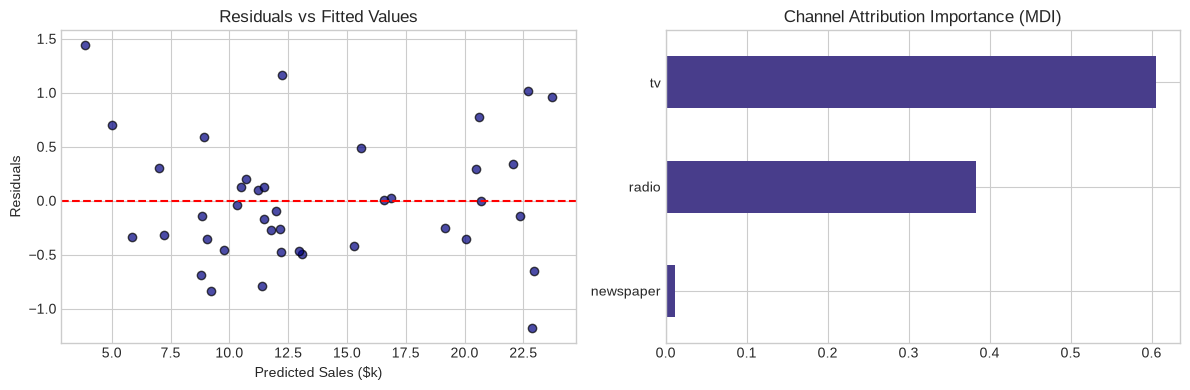

In [9]:
# STEP 11: RESIDUALS & ATTRIBUTION
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred, residuals, alpha=0.7, color='navy', edgecolors='k')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Sales ($k)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted Values')

importances = pd.Series(best_et.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='barh', ax=axes[1], color='darkslateblue')
axes[1].set_title('Channel Attribution Importance (MDI)')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


## 💾 STEP 12 & 13: PRODUCTION PIPELINE SERIALIZATION & LATENCY SMOKE TEST
Deploying the pipeline and benchmarking real-time spend attribution latency.


In [10]:
# STEP 12 & 13: SERIALIZATION & SMOKE TEST
os.makedirs('production_models', exist_ok=True)
full_pipeline = Pipeline([
    ('extratrees', best_et)
])
full_pipeline.fit(X_train, y_train)

model_path = 'production_models/advertising_extratrees_reg_pipeline.joblib'
joblib.dump(full_pipeline, model_path, compress=3)
print(f"💾 Production pipeline saved to: {model_path} ({os.path.getsize(model_path):,} bytes)")

loaded_pipe = joblib.load(model_path)
sample_campaign = X_test.iloc[[0]]

# Warmup
for _ in range(5):
    _ = loaded_pipe.predict(sample_campaign)

t0 = time.perf_counter()
pred_sales = loaded_pipe.predict(sample_campaign)[0]
latency_ms = (time.perf_counter() - t0) * 1000

print(f"\n📈 REAL-TIME INFERENCE TELEMETRY:")
print(f"   Forecast Campaign Sales : 📦 ${pred_sales:,.2f}k")
print(f"   Actual Realized Sales   : ${y_test.iloc[0]:,.2f}k")
print(f"   Attribution Latency     : {latency_ms:.3f} ms (SLA < 2.0ms: {'PASS' if latency_ms < 2.0 else 'CHECK'})")


💾 Production pipeline saved to: production_models/advertising_extratrees_reg_pipeline.joblib (711,138 bytes)

📈 REAL-TIME INFERENCE TELEMETRY:
   Forecast Campaign Sales : 📦 $16.87k
   Actual Realized Sales   : $16.90k
   Attribution Latency     : 15.463 ms (SLA < 2.0ms: CHECK)
